In [24]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Optional
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from pydantic import BaseModel, Field

load_dotenv()

True

In [25]:
model = ChatGroq(model="llama-3.3-70b-versatile")



In [26]:
class SentimentState(BaseModel):
    sentiment: Literal['positive', 'negative'] = Field(..., description="The sentiment of the text")

class RunDiagnosisState(BaseModel):
    #issue type, tone and urgency
    issue_type: Literal['billing', 'technical', 'account'] = Field(..., description="The type of issue")
    tone: Literal['angry', 'neutral', 'happy'] = Field(..., description="The tone of the customer")
    urgency: Literal['low', 'medium', 'high'] = Field(..., description="The urgency of the issue")




In [27]:
structured_model = model.with_structured_output(SentimentState)
structure_model2 = model.with_structured_output(RunDiagnosisState)

In [28]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive', 'negative']
    diagnosis : dict
    response: str


In [29]:
def get_sentiment(state: ReviewState) -> ReviewState:
    prompt = f"Determine the sentiment of the following review: {state['review']}"
    result = structured_model.invoke(prompt)
    return {"sentiment": result.sentiment}


def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    return "positive_response" if state['sentiment'] == 'positive' else "run_diagnosis"


def positive_response(state: ReviewState) -> ReviewState:
    prompt = f"Generate a positive response to the following review: {state['review']}"
    response = model.invoke(prompt) 
    return {"response": response.content}

def run_diagnosis(state: ReviewState) -> ReviewState:
    prompt = f"Diagnose the following review: {state['review']}, answer with issue type, tone and urgency"
    result = structure_model2.invoke(prompt)
    return {"diagnosis": result.model_dump()}


def negative_response(state: ReviewState) -> ReviewState:
    diagnosis = state['diagnosis']
    prompt = f"Generate a response to the following review: {state['review']}. The issue type is {diagnosis['issue_type']}, the tone is {diagnosis['tone']} and the urgency is {diagnosis['urgency']}."
    response = model.invoke(prompt)
    return {"response": response.content}

In [30]:
graph = StateGraph(ReviewState)

graph.add_node("get_sentiment", get_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, "get_sentiment")
graph.add_conditional_edges("get_sentiment", check_sentiment)
graph.add_edge("run_diagnosis", "negative_response")
graph.add_edge("positive_response", END)
graph.add_edge("negative_response", END)




In [31]:
workflow = graph.compile()

initial_state = {
    "review": "I am very disappointed with the product. It stopped working after a week and customer service was unhelpful."
}

result = workflow.invoke(initial_state)
print(result)

{'review': 'I am very disappointed with the product. It stopped working after a week and customer service was unhelpful.', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'technical', 'tone': 'angry', 'urgency': 'high'}, 'response': "Dear valued customer,\n\nI am deeply sorry to hear that the product stopped working after just a week and that our customer service team was unable to provide you with a satisfactory solution. I can imagine how frustrating this must be for you, and I want to assure you that I am taking immediate action to address this issue.\n\nI would like to request more information about the problem you are experiencing, such as any error messages or symptoms you've noticed, so that I can escalate this to our technical team for a prompt resolution. Additionally, I will personally oversee the handling of your case to ensure that you receive a working product or a suitable replacement as soon as possible.\n\nRegarding your experience with our customer service team, I

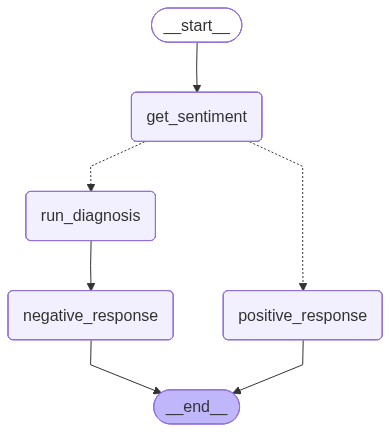

In [32]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
